In [1]:
from models import VDPResNet18
from utils_vdp import gaussian_loss, mc_nll, dirichlet_loss
from layers import MySoftmax


import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn
from torch.nn import CrossEntropyLoss
import torch
import torch.optim as optim

from tqdm import tqdm
import numpy as np


device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

# Train network
# Train sigma
# Compare 

In [2]:


train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # Randomly crop a 32x32 area with padding
    transforms.RandomHorizontalFlip(),     # Randomly flip the image horizontally
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=train_transform)
trainloader = DataLoader(trainset, batch_size=128,
                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=test_transform)
testloader = DataLoader(testset, batch_size=128,
                         shuffle=False, num_workers=2)


def ce_loss(mu, sigma, y):
    criterion = CrossEntropyLoss()
    return criterion(mu, y)


def fgsm_attack(model, x, y, epsilon, idx=0):
    x_adv = x.clone().detach().requires_grad_(True).to(device)
    mu, sigma, kl = model(x_adv)
    if idx != 1:
        mu, sigma = MySoftmax()(mu, sigma)
    loss = ce_loss(mu, sigma, y)
    model.zero_grad()
    loss.backward()
    return (x_adv + epsilon * x_adv.grad.sign()).clamp(0,1)

def pgd_attack(model, x, y, epsilon, alpha=0.01, iters=10, idx=0):
    x_adv = x.clone().detach().to(device)
    x_orig = x.clone().detach().to(device)
    for _ in range(iters):
        x_adv.requires_grad_(True)
        mu, sigma, kl = model(x_adv)
        if idx != 1:
            mu, sigma = MySoftmax()(mu, sigma)
        loss = ce_loss(mu, sigma, y)
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            x_adv = (x_adv + alpha * x_adv.grad.sign()).clamp(x_orig - epsilon, x_orig + epsilon).clamp(0,1)
    return x_adv


In [ ]:
from utils_vdp import gaussian_loss, mc_nll, dirichlet_loss
from layers import MySoftmax
import wandb
from torch.nn import CrossEntropyLoss
import torch
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import torch.nn.functional as F

def dirichlet_loss2(mu, sigma, targets, eps=1e-8, lambda_reg=0.01):
    # 1) build strictly‐positive evidence
    evidence    = F.softplus(mu) / (sigma + eps)      # [B, C]
    alpha       = evidence + 1                        # [B, C]
    alpha_0     = alpha.sum(dim=1)                    # [B]

    # 2) NLL term for a single one‐hot target
    target_oh   = F.one_hot(targets, mu.size(1)).float()
    alpha_t     = (alpha * target_oh).sum(dim=1)      # [B]
    main_loss   = torch.log(alpha_0 + eps) - torch.log(alpha_t + eps)

    # 3) regularize only the uncertainty on the true class
    sigma_t     = (sigma * target_oh).sum(dim=1)      # [B]
    reg_loss    = lambda_reg * sigma_t

    return (main_loss + reg_loss).mean()

loss_list = ["dirichlet", "ce", "gaussian", "mc"]
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
epsilons = [0.01, 0.05, 0.1, 0.15, 0.2]

for idx, loss in enumerate([dirichlet_loss2, ce_loss, gaussian_loss, mc_nll]):
    kl_factor = 0.00001 if idx != 1 else 0.0
    criterion = loss
    lr=0.01
    batch_size = 128
    num_epochs = 200

    net = VDPResNet18(num_classes=10)
    a = net(next(iter(testloader))[0])
    net = net.to(device)
    optimizer = optim.Adam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-7)

    for epoch in tqdm(range(num_epochs)):
        log_dict = {}
        # Training phase
        net.train()
        running_loss, running_kl, correct, total, sigma_mean, sigma_std = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        for i, (inputs, labels) in enumerate(trainloader, 0):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            mu, sigma, kl = net(inputs)
            sigma_mean += sigma.mean(1).sum().item()
            sigma_std += sigma.std(1).sum().item()

            # if idx != 1:
            #     mu, sigma = MySoftmax()(mu, sigma)

            loss = criterion(mu, sigma, labels) + kl_factor * kl
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_kl += kl.item()        
            _, predicted = torch.max(mu, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            

        train_accuracy = 100 * correct / total
        train_loss = running_loss / total
        train_kl = running_kl / total
        sigma_mean /= total
        sigma_std /= total
        
        net.eval()
        correct_test, running_kl_test, running_loss_test, total_test, test_sigma_sd, test_sigma_mean = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device) # Move batch to GPU
            mu, sigma, kl = net(images)
            if idx != 1:
                mu, sigma = MySoftmax()(mu, sigma)
            loss = criterion(mu, sigma, labels) + kl_factor * kl
            
            running_loss_test += loss.item()
            running_kl_test += kl.item()
            _, predicted = torch.max(mu, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
            test_sigma_mean += sigma.mean(1).sum().item()
            test_sigma_sd += sigma.std(1).sum().item()

        test_accuracy = 100 * correct_test / total_test
        test_loss = running_loss_test / total_test
        test_kl = running_kl_test / total_test
        test_sigma_mean = test_sigma_mean / total_test
        test_sigma_sd = test_sigma_sd / total_test


        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, KL: {train_kl:.4f}, '
              f'Accuracy: {train_accuracy:.2f}%, Sigma Mean: {sigma_mean:.4f}, Sigma Std: {sigma_std:.4f}')
        print(f'Test Loss: {test_loss:.4f}, KL: {test_kl:.4f}, '
              f'Accuracy: {test_accuracy:.2f}%, Sigma Mean: {test_sigma_mean:.4f}, Sigma Std: {test_sigma_mean:.4f}')

        scheduler.step(test_accuracy)
        for param_group in optimizer.param_groups:
            current_lr = param_group["lr"]
        print(f"  → LR
    if (epoch+1)%50  == 0:
        torch.save(net.state_dict(), f'models/resnets/CIFAR10/param3_{epoch+1}_{loss_list[idx]}.pth')

  0%|          | 1/200 [01:11<3:56:37, 71.35s/it]

Epoch [1/200], Loss: 0.0147, KL: 74.0381, Accuracy: 33.71%, Sigma Mean: 0.0103, Sigma Std: 0.0015
Test Loss: 0.0300, KL: 79.7870, Accuracy: 43.98%, Sigma Mean: 0.0000, Sigma Std: 0.0000
  → LR is now 1.00e-02


  1%|          | 2/200 [02:21<3:53:34, 70.78s/it]

Epoch [2/200], Loss: 0.0120, KL: 83.5222, Accuracy: 47.94%, Sigma Mean: 0.0106, Sigma Std: 0.0027
Test Loss: 0.0271, KL: 90.6356, Accuracy: 53.29%, Sigma Mean: 0.0000, Sigma Std: 0.0000
  → LR is now 1.00e-02


  2%|▏         | 3/200 [03:32<3:51:41, 70.57s/it]

...

Epoch [110/200], Loss: -0.1447, KL: 868.5857, Accuracy: 93.67%, Sigma Mean: 0.0100, Sigma Std: 0.0072
Test Loss: 265.4398, KL: 877.4223, Accuracy: 84.83%, Sigma Mean: 0.0000, Sigma Std: 0.0000
  → LR is now 1.56e-04


 56%|█████▌    | 111/200 [2:21:54<1:52:57, 76.15s/it]

Epoch [111/200], Loss: -0.1453, KL: 868.4859, Accuracy: 93.78%, Sigma Mean: 0.0100, Sigma Std: 0.0072
Test Loss: 267.5517, KL: 877.3208, Accuracy: 85.13%, Sigma Mean: 0.0000, Sigma Std: 0.0000
  → LR is now 1.56e-04


 56%|█████▌    | 112/200 [2:23:11<1:51:53, 76.29s/it]

Epoch [112/200], Loss: -0.1464, KL: 868.3884, Accuracy: 94.00%, Sigma Mean: 0.0099, Sigma Std: 0.0072
Test Loss: 270.5993, KL: 877.2241, Accuracy: 85.03%, Sigma Mean: 0.0000, Sigma Std: 0.0000
  → LR is now 1.56e-04


In [7]:
from evaluate_models import compare_models

net_dirichlet = VDPResNet18(num_classes=10)
net_dirichlet(next(iter(testloader))[0])
net_dirichlet.load_state_dict(torch.load(f'models/resnets/CIFAR10/param2_100_dirichlet.pth'))
net_dirichlet.to(device)
net_dirichlet.eval()

net_mc = VDPResNet18(num_classes=10)
net_mc(next(iter(testloader))[0])
net_mc.load_state_dict(torch.load(f'models/resnets/CIFAR10/param2_100_mc.pth'))
net_mc.to(device)
net_mc.eval()

net_gaussian = VDPResNet18(num_classes=10)
net_gaussian(next(iter(testloader))[0])
net_gaussian.load_state_dict(torch.load(f'models/resnets/CIFAR10/param2_100_gaussian.pth'))
net_gaussian.to(device)
net_gaussian.eval()

net_ce = VDPResNet18(num_classes=10)
net_ce(next(iter(testloader))[0])
net_ce.load_state_dict(torch.load(f'models/resnets/CIFAR10/param2_100_ce.pth'))
net_ce.to(device)
net_ce.eval()


VDPResNet18(
  (conv1): VDPFirstConv()
  (bn1): VDP_BatchNorm2D()
  (relu): VDP_ReLU()
  (maxpool): VDPMaxPooling()
  (layer11): VDPResnetBasicBlock(
    (conv1): VDPIntermediateConv()
    (bn1): VDP_BatchNorm2D()
    (relu): VDP_ReLU()
    (conv2): VDPIntermediateConv()
    (bn2): VDP_BatchNorm2D()
  )
  (layer12): VDPResnetBasicBlock(
    (conv1): VDPIntermediateConv()
    (bn1): VDP_BatchNorm2D()
    (relu): VDP_ReLU()
    (conv2): VDPIntermediateConv()
    (bn2): VDP_BatchNorm2D()
  )
  (layer21): VDPResnetBasicBlock(
    (conv1): VDPIntermediateConv()
    (bn1): VDP_BatchNorm2D()
    (relu): VDP_ReLU()
    (conv2): VDPIntermediateConv()
    (bn2): VDP_BatchNorm2D()
    (shortcut_conv): VDPIntermediateConv()
    (shortcut_batchnorm): VDP_BatchNorm2D()
  )
  (layer22): VDPResnetBasicBlock(
    (conv1): VDPIntermediateConv()
    (bn1): VDP_BatchNorm2D()
    (relu): VDP_ReLU()
    (conv2): VDPIntermediateConv()
    (bn2): VDP_BatchNorm2D()
  )
  (layer31): VDPResnetBasicBlock(
    (co

In [8]:
oodset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                       download=True, transform=test_transform)
ood_dl = DataLoader(oodset, batch_size=128,
                         shuffle=False, num_workers=2)


compare_models([net_gaussian, net_mc, net_dirichlet, net_ce], testloader, ood_dl, deterministic_idxs=[], noise_strengths=[0.01, 0.03, 0.05, 0.1], num_to_attack=500, device="cuda:2")

finished evaluation of 0th model
finished evaluation of 1th model
finished evaluation of 2th model
finished evaluation of 3th model
Trial 1: Found 627 new common correct samples, total: 627/500
ε=0.010: selected 500 samples
Trial 1: Found 576 new common correct samples, total: 576/500
ε=0.030: selected 500 samples
Trial 1: Found 584 new common correct samples, total: 584/500
ε=0.050: selected 500 samples


OutOfMemoryError: CUDA out of memory. Tried to allocate 18.00 MiB. GPU 2 has a total capacity of 47.38 GiB of which 9.69 MiB is free. Including non-PyTorch memory, this process has 47.36 GiB memory in use. Of the allocated memory 46.64 GiB is allocated by PyTorch, and 223.64 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [3]:
import pandas as pd

def compute_top_results(results_list, top_n=3, fmt="{:.4f} ({})"):
    """
    Given a list of dicts where each key is "<criterion>_<metric>"
    and each value is a float, return a dict of DataFrames—one per metric—
    showing the top_n results per model.

    Args:
        results_list: List[Dict[str, float]]
        top_n: how many rows to keep (default 3)
        fmt: format string for each cell; must have two placeholders: value, criterion

    Returns:
        Dict[str, pd.DataFrame]  mapping metric name (e.g. "AUPR") to DataFrame
    """
    metrics = ["aupr", "auroc", "fpr95"]
    # fpr95 we want lowest first; the others, highest first
    orders = {m: (True if m == "fpr95" else False) for m in metrics}

    dfs = {}
    for m in metrics:
        ascending = orders[m]
        idx = [f"top{i+1}" for i in range(top_n)]
        df = pd.DataFrame(index=idx)

        for i, res in enumerate(results_list, start=1):
            # collect all (value, criterion) for this metric
            pairs = []
            for key, val in res.items():
                crit, met = key.rsplit("_", 1)
                if met.lower() == m:
                    pairs.append((float(val), crit))
            # sort and take top_n
            pairs = sorted(pairs, key=lambda x: x[0], reverse=not ascending)[:top_n]
            # format and pad
            formatted = [fmt.format(v, crit) for v, crit in pairs]
            while len(formatted) < top_n:
                formatted.append("")
            df[f"model{i}"] = formatted

        dfs[m.upper()] = df

    return dfs

# --- example usage with your data ---

import numpy as np

results_list = [
  {'max_output_auroc': np.float64(0.779225405),
   'max_output_aupr': np.float64(0.808538212513715),
   'max_output_fpr95': np.float64(0.8177),
   'mean_output_sigma_auroc': np.float64(0.776154185),
   'mean_output_sigma_aupr': np.float64(0.8071653108220702),
   'mean_output_sigma_fpr95': np.float64(0.8421),
   'max_output_sigma_auroc': np.float64(0.777822145),
   'max_output_sigma_aupr': np.float64(0.8087740956669607),
   'max_output_sigma_fpr95': np.float64(0.8449),
   'entropy_auroc': np.float64(0.785970645),
   'entropy_aupr': np.float64(0.8113911011048796),
   'entropy_fpr95': np.float64(0.7969),
   'mean_logits_sigma_auroc': np.float64(0.7778907899999999),
   'mean_logits_sigma_aupr': np.float64(0.7946555472082768),
   'mean_logits_sigma_fpr95': np.float64(0.7969),
   'max_logits_sigma_auroc': np.float64(0.54966644),
   'max_logits_sigma_aupr': np.float64(0.5640404843006939),
   'max_logits_sigma_fpr95': np.float64(0.9877),
   'full_mc_auroc': np.float64(0.7859846),
   'full_mc_aupr': np.float64(0.8113982826203626),
   'full_mc_fpr95': np.float64(0.7968),
   'epistemic_mc_auroc': np.float64(0.78069766),
   'epistemic_mc_aupr': np.float64(0.8050704966467536),
   'epistemic_mc_fpr95': np.float64(0.8105),
   'aleatoric_mc_auroc': np.float64(0.7859872450000001),
   'aleatoric_mc_aupr': np.float64(0.8114005548557458),
   'aleatoric_mc_fpr95': np.float64(0.7968)},
  {'max_output_auroc': np.float64(0.787845485),
   'max_output_aupr': np.float64(0.8211895550814563),
   'max_output_fpr95': np.float64(0.8317),
   'mean_output_sigma_auroc': np.float64(0.7872621550000001),
   'mean_output_sigma_aupr': np.float64(0.821346904301366),
   'mean_output_sigma_fpr95': np.float64(0.8407),
   'max_output_sigma_auroc': np.float64(0.78761052),
   'max_output_sigma_aupr': np.float64(0.8210945589469427),
   'max_output_sigma_fpr95': np.float64(0.8317),
   'entropy_auroc': np.float64(0.79128508),
   'entropy_aupr': np.float64(0.8233608880833618),
   'entropy_fpr95': np.float64(0.8019),
   'mean_logits_sigma_auroc': np.float64(0.73121035),
   'mean_logits_sigma_aupr': np.float64(0.749605698915742),
   'mean_logits_sigma_fpr95': np.float64(0.8401),
   'max_logits_sigma_auroc': np.float64(0.7312094400000001),
   'max_logits_sigma_aupr': np.float64(0.7496036268021986),
   'max_logits_sigma_fpr95': np.float64(0.8401),
   'full_mc_auroc': np.float64(0.791299685),
   'full_mc_aupr': np.float64(0.8233683444647922),
   'full_mc_fpr95': np.float64(0.8022),
   'epistemic_mc_auroc': np.float64(0.786755035),
   'epistemic_mc_aupr': np.float64(0.8037367731865633),
   'epistemic_mc_fpr95': np.float64(0.8226),
   'aleatoric_mc_auroc': np.float64(0.791304985),
   'aleatoric_mc_aupr': np.float64(0.8233710847603098),
   'aleatoric_mc_fpr95': np.float64(0.8014)}
]

dfs = compute_top_results(results_list)

for metric, df in dfs.items():
    print(metric)
    print(df, "\n")


AUPR
                     model1                 model2
top1  0.8114 (aleatoric_mc)  0.8234 (aleatoric_mc)
top2       0.8114 (full_mc)       0.8234 (full_mc)
top3       0.8114 (entropy)       0.8234 (entropy) 

AUROC
                     model1                 model2
top1  0.7860 (aleatoric_mc)  0.7913 (aleatoric_mc)
top2       0.7860 (full_mc)       0.7913 (full_mc)
top3       0.7860 (entropy)       0.7913 (entropy) 

FPR95
                     model1                 model2
top1       0.7968 (full_mc)  0.8014 (aleatoric_mc)
top2  0.7968 (aleatoric_mc)       0.8019 (entropy)
top3       0.7969 (entropy)       0.8022 (full_mc) 



In [ ]:
def compute_top_results(results_list, top_n=3, fmt="{:.4f} ({})"):
    metrics = ["aupr", "auroc", "fpr95"]
    orders = {m: (True if m == "fpr95" else False) for m in metrics}
    dfs_fmt = {}
    numeric_dfs = {}
    for m in metrics:
        asc = orders[m]
        idx = [f"top{i+1}" for i in range(top_n)]
        df_fmt = pd.DataFrame(index=idx)
        df_num = pd.DataFrame(index=idx)
        for i, res in enumerate(results_list, start=1):
            pairs = [(float(v), k.rsplit("_",1)[0]) 
                     for k, v in res.items() if k.endswith(f"_{m}")]
            sorted_pairs = sorted(pairs, key=lambda x: x[0], reverse=not asc)[:top_n]
            vals = [v for v, _ in sorted_pairs]
            crits = [crit for _, crit in sorted_pairs]
            # format
            fmted = [fmt.format(v, crit) for v, crit in sorted_pairs]
            # pad
            while len(fmted) < top_n:
                fmted.append("")
                vals.append(np.nan)
            df_fmt[f"model{i}"] = fmted
            df_num[f"model{i}"] = vals
        dfs_fmt[m.upper()] = df_fmt
        numeric_dfs[m.upper()] = df_num
    return dfs_fmt, numeric_dfs

# compute



gaussian_list = [{0.01: 0.9905}, {0.01: 0.9933}]
fgsm_dict = {0.01: {'robustness': [[0.622, 0.648], [0.672, 0.672]]}}
pgm_dict = {0.01: {'robustness': [[0.406, 0.618], [0.67, 0.532]]}}

# Build Gaussian DataFrame
def display_robustness(gaussian_list, fgsm_dict, pgm_dict):
    epsilons = sorted({list(d.keys())[0] for d in gaussian_list})
    Gaussian_df = pd.DataFrame(index=epsilons)
    for i, d in enumerate(gaussian_list, start=1):
        Gaussian_df[f"model{i}"] = [d[eps] for eps in epsilons]
    Gaussian_df.index.name = "epsilon"

    # Build FGSM DataFrame
    epsilons = sorted(fgsm_dict.keys())
    FGSM_df = pd.DataFrame(index=epsilons)
    num_models = len(next(iter(fgsm_dict.values()))['robustness'])
    for j in range(num_models):
        FGSM_df[f"model{j+1}"] = [np.mean(fgsm_dict[eps]['robustness'][j]) for eps in epsilons]
    FGSM_df.index.name = "epsilon"

    # Build PGM DataFrame
    epsilons = sorted(pgm_dict.keys())
    PGM_df = pd.DataFrame(index=epsilons)
    num_models = len(next(iter(pgm_dict.values()))['robustness'])
    for j in range(num_models):
        PGM_df[f"model{j+1}"] = [np.mean(pgm_dict[eps]['robustness'][j]) for eps in epsilons]
    PGM_df.index.name = "epsilon"

    # Styling function: highlight highest in red, second-highest in blue per row
    def style_df_highlights(df):
        def highlight_row(row):
            vals = row.values.astype(float)
            order = (-vals).argsort()  # descending for highest first
            styles = [''] * len(vals)
            if len(vals) > 0:
                styles[order[0]] = 'color: red'
            if len(vals) > 1:
                styles[order[1]] = 'color: blue'
            return styles
        return df.style.apply(highlight_row, axis=1)

    # Apply styling and display
    styled_Gaussian = style_df_highlights(Gaussian_df)
    styled_FGSM = style_df_highlights(FGSM_df)
    styled_PGM = style_df_highlights(PGM_df)

    print("Gaussian")
    display(styled_Gaussian)

    print("FGSM")
    display(styled_FGSM)

    print("PGM")
    display(styled_PGM)

AUPR


,model1,model2
top1,0.8114 (aleatoric_mc),0.8234 (aleatoric_mc)
top2,0.8114 (full_mc),0.8234 (full_mc)
top3,0.8114 (entropy),0.8234 (entropy)


AUROC


,model1,model2
top1,0.7860 (aleatoric_mc),0.7913 (aleatoric_mc)
top2,0.7860 (full_mc),0.7913 (full_mc)
top3,0.7860 (entropy),0.7913 (entropy)


FPR95


...

,model1,model2
epsilon,,
0.010000,0.990500,0.993300


FGSM


,model1,model2
epsilon,,
0.010000,0.635000,0.672000


PGM


,model1,model2
epsilon,,
0.010000,0.512000,0.601000


In [7]:
oodset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                       download=True, transform=test_transform)
ood_dl = DataLoader(oodset, batch_size=128,
                         shuffle=False, num_workers=2)


compare_models([net_dirichlet, net_ce], testloader, ood_dl, deterministic_idxs=[], noise_strengths=[0.01, 0.03,0.05,0.1], num_to_attack=500, device="cuda:2")

finished evaluation of 0th model
finished evaluation of 1th model
Trial 1: Found 796 new common correct samples, total: 796/500
ε=0.010: selected 500 samples
Trial 1: Found 757 new common correct samples, total: 757/500
ε=0.030: selected 500 samples
Trial 1: Found 784 new common correct samples, total: 784/500
ε=0.050: selected 500 samples
Trial 1: Found 787 new common correct samples, total: 787/500
ε=0.100: selected 500 samples
Trial 1: Found 768 new common correct samples, total: 768/500
ε=0.010: selected 500 samples
Trial 1: Found 750 new common correct samples, total: 750/500
ε=0.030: selected 500 samples


OutOfMemoryError: CUDA out of memory. Tried to allocate 18.00 MiB. GPU 2 has a total capacity of 47.38 GiB of which 17.69 MiB is free. Including non-PyTorch memory, this process has 47.35 GiB memory in use. Of the allocated memory 46.63 GiB is allocated by PyTorch, and 223.68 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
net = VDPResNet18(num_classes=10)
a = net(next(iter(testloader))[0])
num_epochs = 100
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
net.to(device)
optimizer = optim.Adam(net.get_parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()


for epoch in range(num_epochs):
    # Training phase
    net.train()
    running_loss, correct, total = 0.0, 0.0, 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move batch to GPU
        optimizer.zero_grad()
        mu, sigma, kl = net(inputs)
        loss = criterion(mu, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(mu, 1)
        running_loss += loss.item()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    running_loss = 0.0
    train_accuracy = 100 * correct / total

    # Validation phase
    net.eval()  # Set the net to evaluation mode
    correct = 0
    total = 0
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device) # Move batch to GPU
        mu, sigma, kl = net(images)
        _, predicted = torch.max(mu, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Epoch {epoch + 1} validation accuracy: {accuracy:.2f}% train accuracy: {train_accuracy:.2f}%')
    if (epoch+1)%50 == 0:
        torch.save(net, f"resnets/CIFAR10/resnet_cifar10_deterministic_{epoch+1}_2.pth")

Epoch 1 validation accuracy: 42.47% train accuracy: 30.25%
Epoch 2 validation accuracy: 48.49% train accuracy: 44.42%
Epoch 3 validation accuracy: 57.70% train accuracy: 53.58%
Epoch 4 validation accuracy: 64.09% train accuracy: 59.46%
Epoch 5 validation accuracy: 64.87% train accuracy: 63.57%
Epoch 6 validation accuracy: 67.24% train accuracy: 66.39%
Epoch 7 validation accuracy: 68.77% train accuracy: 68.76%
Epoch 8 validation accuracy: 70.43% train accuracy: 70.92%
Epoch 9 validation accuracy: 72.95% train accuracy: 72.26%
Epoch 10 validation accuracy: 73.59% train accuracy: 73.91%
Epoch 11 validation accuracy: 75.69% train accuracy: 75.06%
Epoch 12 validation accuracy: 73.71% train accuracy: 76.05%
Epoch 13 validation accuracy: 76.39% train accuracy: 76.67%
Epoch 14 validation accuracy: 77.02% train accuracy: 77.75%
Epoch 15 validation accuracy: 77.07% train accuracy: 78.47%
Epoch 16 validation accuracy: 77.13% train accuracy: 79.32%
Epoch 17 validation accuracy: 79.11% train accura

In [3]:
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=test_transform)
test_dl = DataLoader(testset, batch_size=128,
                         shuffle=False, num_workers=2)

oodset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                       download=True, transform=test_transform)
ood_dl = DataLoader(oodset, batch_size=128,
                         shuffle=False, num_workers=2)


In [4]:
from evaluate_models import compare_models
net_deterministic = torch.load("resnets/CIFAR10/resnet_cifar10_deterministic_100.pth", weights_only=False)
net_gaussian = torch.load("resnets/CIFAR10/resnet_cifar10_gaussian_100.pth", weights_only=False)
net_dirichlet = torch.load("resnets/CIFAR10/resnet_cifar10_dirichlet_100.pth", weights_only=False)

In [13]:
import numpy as np
np.std([s.mean().item() for s in net_dirichlet.get_parameters_sigma()]).item()

0.007645414810879641

In [18]:
list(net_dirichlet.get_parameters_sigma())

[Parameter containing:
 tensor([-4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000],
        device='cuda:3', requires_grad=True),
 Parameter containing:
 tensor([-4.5950, -4.5950, -4.5950, -4.5950, -4.5950, -4.5950, -4.5950, -4.5950,
         -4.5950, -4.5950, -4.5950, -4.5950, -4.5950, -4.5950, -4.5950, -4.5950,
         -4.5950, -4.5950, -4.5950, -4.5950, -4.5950, -4.5950, -4.5950, -4.5950,
         -4.5950

In [8]:
rrr = compare_models([net_deterministic, net_gaussian, net_dirichlet], test_dl, ood_dl, deterministic_idxs=[], device=torch.device("cuda:2"))

finished evaluation of 0th model
finished evaluation of 1th model
finished evaluation of 2th model
Trial 1: Found 2821 new common correct samples, total: 2821/2000
ε=0.010: selected 2000 samples
Trial 1: Found 2767 new common correct samples, total: 2767/2000
ε=0.010: selected 2000 samples


In [9]:
rrr

([{'max_output_auroc': np.float64(0.7858261200000001),
   'max_output_aupr': np.float64(0.8204614582509113),
   'max_output_fpr95': np.float64(0.8245),
   'mean_output_sigma_auroc': np.float64(0.765602625),
   'mean_output_sigma_aupr': np.float64(0.8023971758500086),
   'mean_output_sigma_fpr95': np.float64(0.8391),
   'max_output_sigma_auroc': np.float64(0.7738565900000001),
   'max_output_sigma_aupr': np.float64(0.8084700944293249),
   'max_output_sigma_fpr95': np.float64(0.8382),
   'entropy_auroc': np.float64(0.79215842),
   'entropy_aupr': np.float64(0.8231359592935559),
   'entropy_fpr95': np.float64(0.792),
   'mean_logits_sigma_auroc': np.float64(0.77712751),
   'mean_logits_sigma_aupr': np.float64(0.8071293759501202),
   'mean_logits_sigma_fpr95': np.float64(0.8217),
   'max_logits_sigma_auroc': np.float64(0.7228153549999999),
   'max_logits_sigma_aupr': np.float64(0.7369004009705294),
   'max_logits_sigma_fpr95': np.float64(0.8448),
   'full_mc_auroc': np.float64(0.79638052),

In [18]:
# Proper implementation

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # Randomly crop a 32x32 area with padding
    transforms.RandomHorizontalFlip(),     # Randomly flip the image horizontally
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=test_transform)
test_dl = DataLoader(testset, batch_size=128,
                         shuffle=False, num_workers=2)

oodset = torchvision.datasets.CIFAR100(root='./data', train=False,
                                       download=True, transform=test_transform)
ood_dl = DataLoader(oodset, batch_size=128,
                         shuffle=False, num_workers=2)


In [4]:
import torch
import numpy as np

# define device
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

def calculate_entropy(predictions: torch.Tensor, epsilon: float = 1e-12) -> np.ndarray:
    # clamp to avoid log(0), re‐normalize, compute entropy
    p = torch.clamp(predictions, min=epsilon)
    p = p / p.sum(dim=-1, keepdim=True)
    ent = -torch.sum(p * torch.log(p), dim=-1)
    return ent.detach().cpu().numpy()

def get_ood_indicators(train_dl, ood_dl, net) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    all_sigmas      = []
    all_sigmas_log  = []
    all_entropy     = []
    all_labels      = []
    
    # helper to process one batch
    def process_batch(x, label_value):
        x = x.to(device)
        mu_logit, sigma_logit, _ = net(x)
        mu, sigma = MySoftmax()(mu_logit, sigma_logit)
        
        # compute and collect
        all_entropy.append(calculate_entropy(mu))
        all_sigmas.append(     sigma.mean(dim=1).detach().cpu().numpy())
        all_sigmas_log.append( sigma_logit.mean(dim=1).detach().cpu().numpy())
        all_labels.append(     np.full((x.size(0),), label_value, dtype=np.int64))
    
    # in‐distribution = 0
    for xb, _ in train_dl:
        process_batch(xb, label_value=0)
    # out‐of‐distribution = 1
    for xb, _ in ood_dl:
        process_batch(xb, label_value=1)
    
    # concatenate
    sigmas      = np.concatenate(all_sigmas)
    sigmas_log  = np.concatenate(all_sigmas_log)
    entropy_vals= np.concatenate(all_entropy)
    labels      = np.concatenate(all_labels)
    
    # shuffle all four arrays with the same perm
    perm = np.random.permutation(len(labels))
    return (
        sigmas[perm],
        sigmas_log[perm],
        entropy_vals[perm],
        labels[perm],
    )


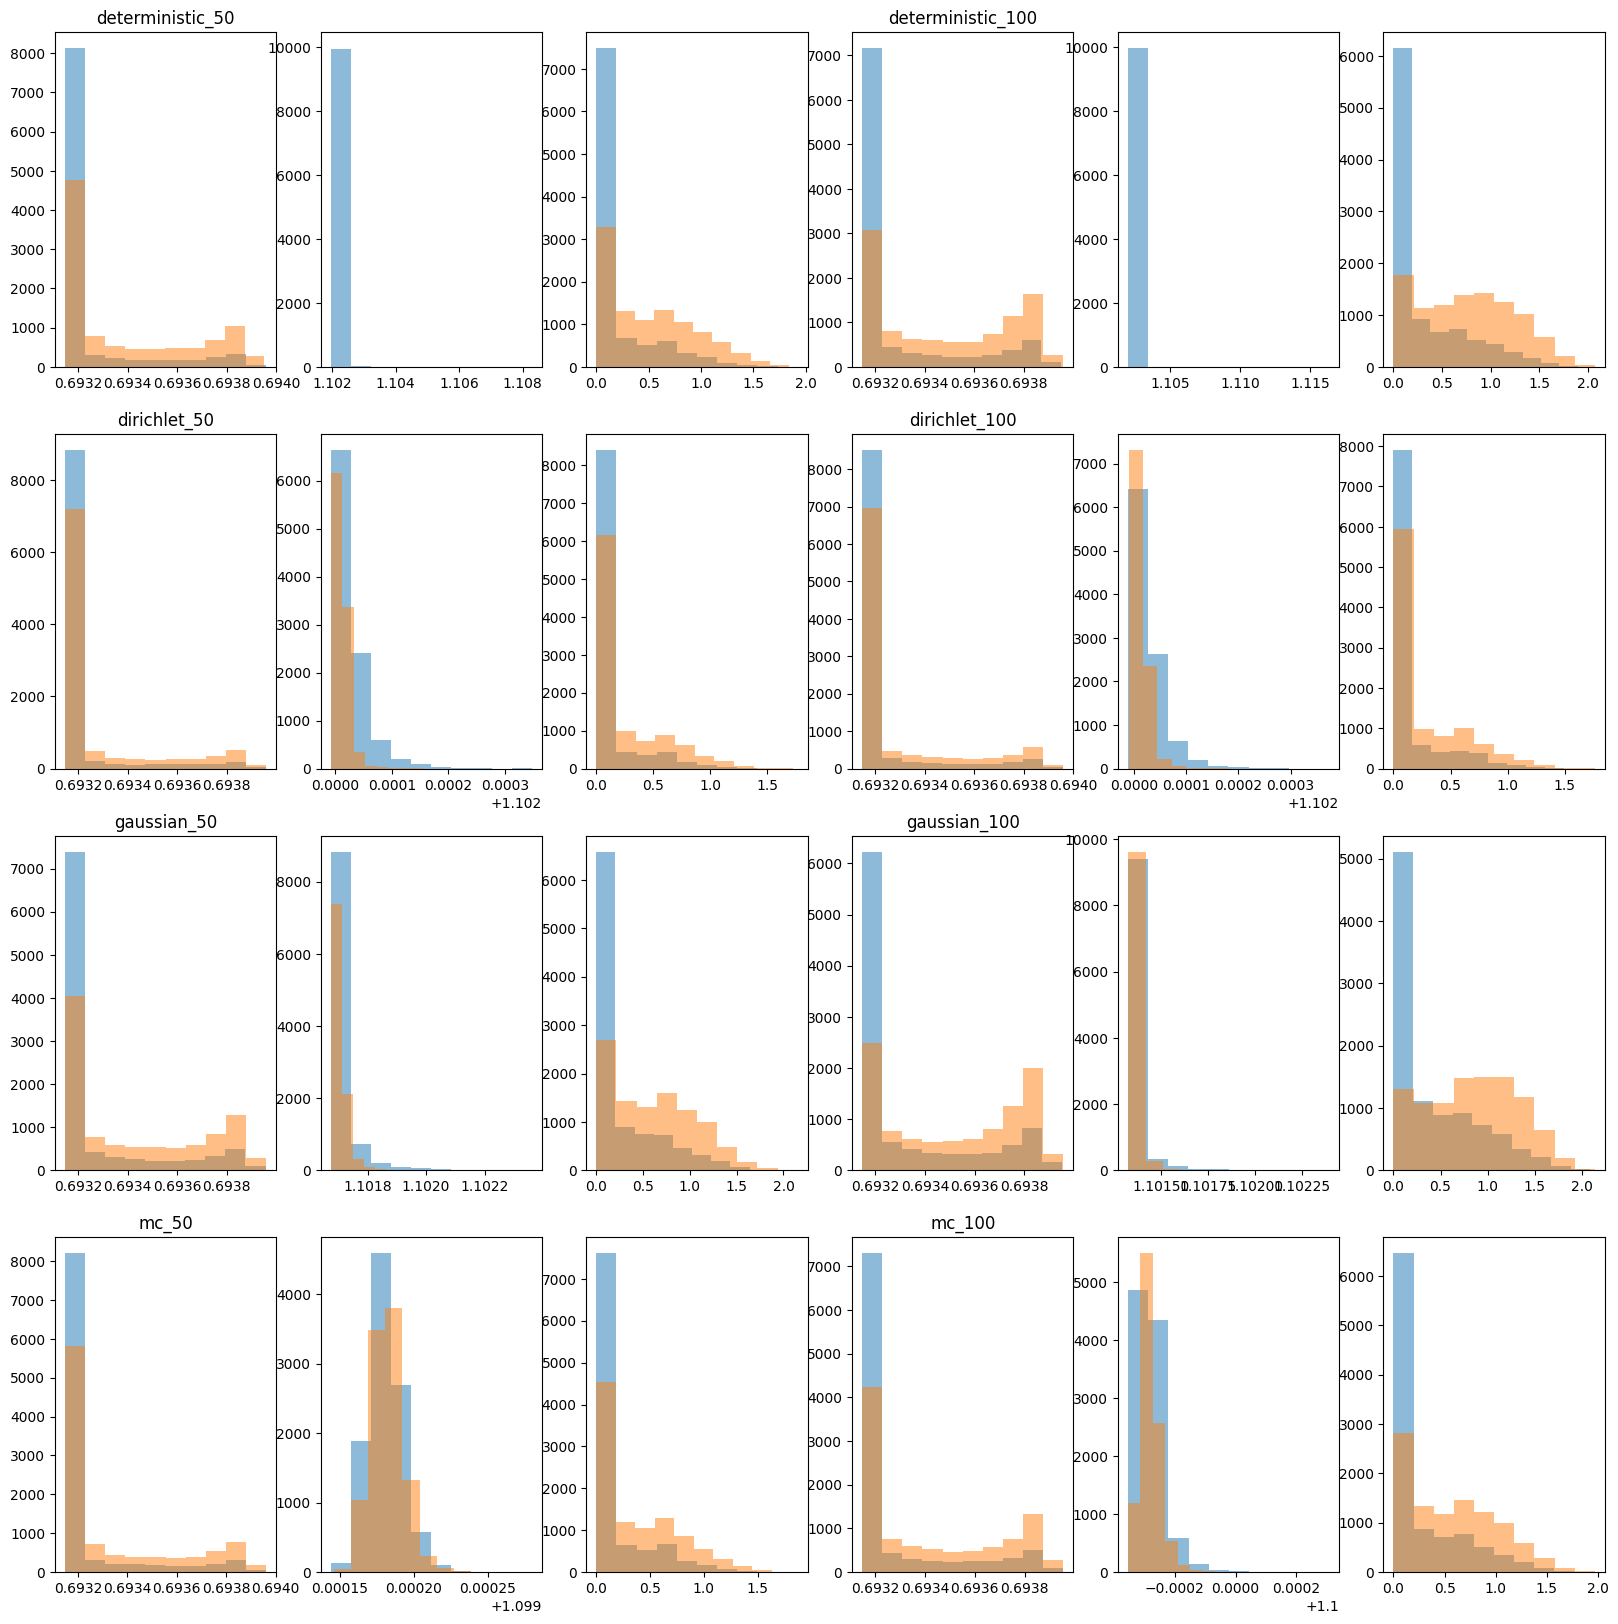

In [5]:
import os
import matplotlib.pyplot as plt


models = os.listdir('resnets/CIFAR10')
models = list(sorted(models))
fig, axs = plt.subplots(len(models)//2, 6, figsize=(20,20))
for i in range(len(models)//2):
    for col, num in enumerate([50, 100]):
        net = torch.load('resnets/CIFAR10/' + models[2*i+col], weights_only=False)
        net.eval()
        sigmas, sigmas_logit, h, d = get_ood_indicators(test_dl, ood_dl, net)
        title = models[2*i + col].split("_")[2]

        axs[i,3*col].hist(sigmas[d==0], alpha=0.5)
        axs[i,3*col].hist(sigmas[d==1], alpha=0.5)
        axs[i,3*col+1].hist(sigmas_logit[d==0], alpha=0.5)
        axs[i,3*col+1].hist(sigmas_logit[d==1], alpha=0.5)
        axs[i,3*col+2].hist(h[d==0], alpha=0.5)
        axs[i,3*col+2].hist(h[d==1], alpha=0.5)
        
        axs[i,3*col].set_title(f"{title}_{num}")


In [ ]:
torch.save(net, "resnet_cifar10.pth")

In [8]:
from utils_vdp import gaussian_loss, mc_nll, dirichlet_loss
from layers import MySoftmax
num_epochs = 5
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
net.to(device)
optimizer = optim.Adam(net.get_parameters_sigma(), lr=0.0001)
kl_factor = 0.00001
criterion = dirichlet_loss


for epoch in range(num_epochs):
    # Training phase
    net.eval()
    running_loss, running_kl, correct, total = 0.0, 0.0, 0.0, 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move batch to GPU
        optimizer.zero_grad()
        mu, sigma, kl = net(inputs)
        mu, sigma = MySoftmax()(mu, sigma)
        loss = criterion(mu, sigma, labels) + kl_factor * kl
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_kl += kl.item()        
        _, predicted = torch.max(mu, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    train_accuracy = 100 * correct / total
    train_loss = running_loss / total
    train_kl = running_kl / total
    
    net.eval()
    correct, running_kl, running_loss, total = 0.0, 0.0, 0.0, 0.0
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device) # Move batch to GPU
        mu, sigma, kl = net(images)
    
        running_loss += loss.item()
        running_kl += kl.item()
        _, predicted = torch.max(mu, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_loss = running_loss / total
    test_kl = running_kl / total
    print(f'Epoch {epoch + 1} training accuracy: {accuracy:.2f}% train loss: {train_loss:.5f} kl {train_kl:.2f} validation loss : {test_loss:.5f} kl {test_kl:.2f}')

Epoch 1 training accuracy: 83.04% train loss: 0.18 kl 17203.77 validation loss : 0.19 kl 17379.76
Epoch 2 training accuracy: 83.04% train loss: 0.18 kl 17203.75 validation loss : 0.19 kl 17379.75
Epoch 3 training accuracy: 83.04% train loss: 0.18 kl 17203.74 validation loss : 0.19 kl 17379.73
Epoch 4 training accuracy: 83.04% train loss: 0.18 kl 17203.72 validation loss : 0.19 kl 17379.72
Epoch 5 training accuracy: 83.04% train loss: 0.18 kl 17203.71 validation loss : 0.19 kl 17379.70


In [4]:
import numpy as np
def calculate_entropy(predictions, epsilon=1e-12):
    predictions = torch.clamp(predictions, min=epsilon)
    predictions = predictions / predictions.sum(dim=-1, keepdim=True)
    return -torch.sum(predictions * torch.log(predictions), dim=-1).detach().cpu().numpy()

def get_ood_indicators(train_dl, ood_dl, net):
    sigmas_logit = []
    sigmas = []
    h =      []
    d =      []
    for x,y in train_dl:
        x = x.to(device)
        mu_logit, sigma_logit, _ = net(x)
        mu, sigma = MySoftmax()(mu_logit, sigma_logit)
        entropy = calculate_entropy(mu)
        sigmas.append(torch.mean(sigma, dim=1).detach().cpu().numpy())
        sigmas_logit.append(torch.mean(sigma_logit, dim=1).detach().cpu().numpy())
        h.append(entropy)
        d.append([0] * len(y))

    for x,y in ood_dl:
        x = x.to(device)
        mu, sigma, _ = net(x)
        entropy = calculate_entropy(mu)
        sigmas.append(torch.mean(sigma, dim=1).detach().cpu().numpy())
        h.append(entropy)
        d.append([1] * len(y))
    
    sigmas = np.concatenate(sigmas)
    h = np.concatenate(h)
    d = np.concatenate(d)

    perm_ids = np.random.permutation(len(h))
    sigmas = sigmas[perm_ids]
    h = h[perm_ids]
    d = d[perm_ids]
    
    return sigmas, sigmas_logit, h, d

In [31]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.special import digamma
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
def cmi_ksg(h, sigma, d, k=5):
    """
    Estimate I(D; sigma | H) using the KSG (Frenzel & Pompe) estimator.
    
    Parameters:
    - h: array-like, shape (n_samples,)
    - sigma: array-like, shape (n_samples,)
    - d: array-like, binary labels (0 or 1) shape (n_samples,)
    - k: number of neighbors
    
    Returns:
    - cmi estimate (float)
    """
    # Stack arrays
    x = sigma.reshape(-1, 1)
    y = d.reshape(-1, 1)
    z = h.reshape(-1, 1)
    xyz = np.hstack([x, y, z])
    xz = np.hstack([x, z])
    yz = np.hstack([y, z])
    z_only = z
    
    n = len(h)
    # Find k-th neighbor distances in joint space (xyz)
    nbrs_xyz = NearestNeighbors(n_neighbors=k+1, metric='chebyshev').fit(xyz)
    distances, _ = nbrs_xyz.kneighbors(xyz)
    eps = distances[:, k]  # distance to k-th neighbor
    
    # Count neighbors within eps (minus self)
    def count_neighbors(data, eps):
        nbrs = NearestNeighbors(metric='chebyshev').fit(data)
        counts = np.array([len(idx)-1 for idx in nbrs.radius_neighbors(data, radius=eps, return_distance=False)])
        return counts
    
    nxz = count_neighbors(xz, eps)
    nyz = count_neighbors(yz, eps)
    nz = count_neighbors(z_only, eps)
    
    # Compute CMI
    cmi = np.mean(digamma(k) + digamma(nz + 1) - digamma(nxz + 1) - digamma(nyz + 1))
    return cmi

def permutation_test(h, sigma, d, k=5, bins=100, n_perm=200):
    """
    Permutation test for conditional independence:
    Shuffle sigma within H-bins to approximate null I(D; sigma | H)=0.
    
    Returns:
    - observed CMI
    - p-value
    """
    obs_cmi = cmi_ksg(h, sigma, d, k)
    # Bin H
    bin_indices = np.digitize(h, np.percentile(h, np.linspace(0, 100, bins+1)))
    perm_cmis = []
    for _ in tqdm(range(n_perm)):
        sigma_shuffled = sigma.copy()
        for b in np.unique(bin_indices):
            mask = bin_indices == b
            sigma_shuffled[mask] = np.random.permutation(sigma_shuffled[mask])
        perm_cmis.append(cmi_ksg(h, sigma_shuffled, d, k))
    perm_cmis = np.array(perm_cmis)
    p_val = np.mean(perm_cmis >= obs_cmi)
    return obs_cmi, p_val, perm_cmis


In [ ]:
ood = "CIFAR100"
if ood=="SVHN":
    ood_ds = torchvision.datasets.SVHN(root='./data',
                                        download=True, transform=train_transform)
elif ood=="CIFAR100":
    ood_ds = torchvision.datasets.CIFAR100(root='./data', train=True,
                                        download=True, transform=train_transform)


ood_dl = DataLoader(trainset, batch_size=128,
                          shuffle=True, num_workers=2)


def empirical_cdf_transform(x):
    # returns vector of same shape, in (0,1), uniform marginal
    ranks = np.argsort(np.argsort(x))
    return ranks / (len(x) - 1.)
net = torch.load('resnets/CIFAR10/resnet_cifar10_gaussian_100.pth', weights_only=False)
sigmas, sigmas_logit, h, d = get_ood_indicators(trainloader, ood_dl, net)
h_proc   = empirical_cdf_transform(h)
sigma_proc = empirical_cdf_transform(sigmas)
print("aaa")

obs_cmi, p_val, perm_dist = permutation_test(h_proc, sigma_proc, d)
print(f"Observed CMI: {obs_cmi:.4f}, p-value: {p_val:.3f}")

KeyboardInterrupt: 

(array([3.2266e+04, 1.3563e+04, 2.8230e+03, 7.9200e+02, 3.0600e+02,
        1.4200e+02, 6.1000e+01, 3.1000e+01, 1.1000e+01, 5.0000e+00]),
 array([1.10198653, 1.10202157, 1.10205662, 1.10209167, 1.10212672,
        1.10216177, 1.10219681, 1.10223186, 1.10226691, 1.10230196,
        1.102337  ]),
 <BarContainer object of 10 artists>)

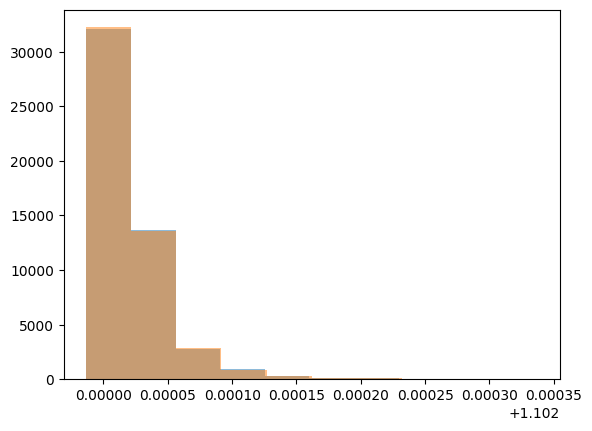

In [55]:
plt.hist(sigmas[d==0], alpha=0.5)
plt.hist(sigmas[d==1], alpha=0.5)

(array([5032., 4955., 5042., 5053., 4988., 4924., 4943., 5025., 5046.,
        4992.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

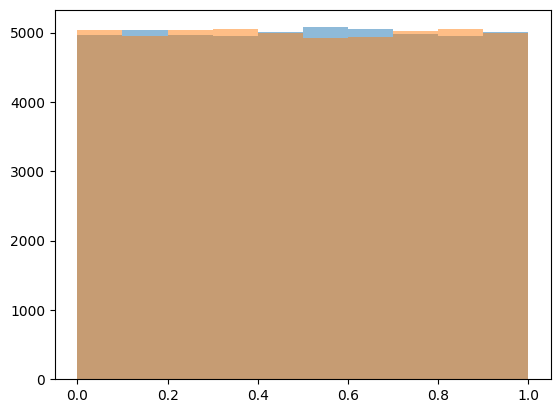

In [54]:
plt.hist(h_proc[d==0], alpha=0.5)
plt.hist(h_proc[d==1], alpha=0.5)

In [36]:
sigmas, h, d = get_ood_indicators(trainloader, ood_dl, net)

In [46]:
print(np.mean(h), max(h)-min(h), np.mean(sigmas), max(sigmas)-min(sigmas))

0.88189834 1.8418893 1.102023 0.00031149387


(array([ 1770.,  3557.,  8313., 16685., 21133., 22920., 15881.,  7691.,
         1864.,   186.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.90000004,
        1.        ]),
 <BarContainer object of 10 artists>)

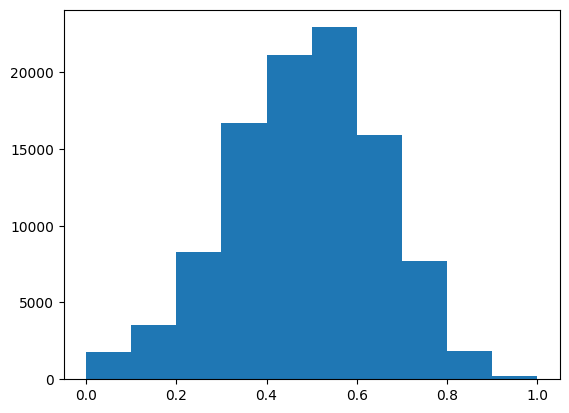

In [40]:
plt.hist((h - min(h))/(max(h)-min(h)))

In [41]:
sss = np.exp(sigmas)

(array([6.9878e+04, 2.3033e+04, 4.6760e+03, 1.4650e+03, 5.5700e+02,
        2.3400e+02, 1.1000e+02, 3.3000e+01, 1.2000e+01, 2.0000e+00]),
 array([3.01015282, 3.01025581, 3.01035881, 3.01046205, 3.01056504,
        3.01066804, 3.01077104, 3.01087403, 3.01097727, 3.01108027,
        3.01118326]),
 <BarContainer object of 10 artists>)

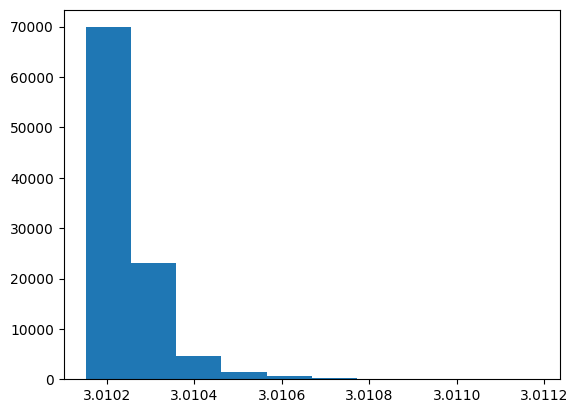

(array([6.9878e+04, 2.3079e+04, 4.6300e+03, 1.4650e+03, 5.5700e+02,
        2.3400e+02, 1.1000e+02, 3.3000e+01, 1.2000e+01, 2.0000e+00]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.90000004,
        1.        ]),
 <BarContainer object of 10 artists>)

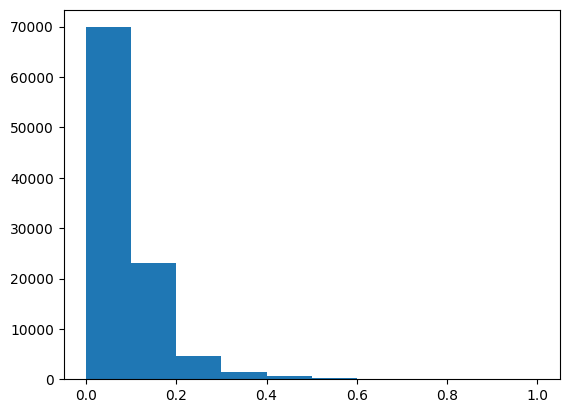

In [43]:
plt.hist((sss - min(sss))/(max(sss)-min(sss)))

In [34]:
for i in range(5):
    ood = "CIFAR100"
    if ood=="SVHN":
        ood_ds = torchvision.datasets.SVHN(root='./data',
                                            download=True, transform=train_transform)
    elif ood=="CIFAR100":
        ood_ds = torchvision.datasets.CIFAR100(root='./data', train=True,
                                            download=True, transform=train_transform)


    ood_dl = DataLoader(trainset, batch_size=128,
                            shuffle=True, num_workers=2)


    def remove_outliers_iqr(data, k=1.5):
        data = np.array(data)
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower_bound = q1 - k * iqr
        upper_bound = q3 + k * iqr
        return (data >= lower_bound) & (data <= upper_bound)

    net = torch.load('resnets/CIFAR10/resnet_cifar10_dirichlet_100.pth', weights_only=False)
    sigmas, h, d = get_ood_indicators(trainloader, ood_dl, net)
    print("aaa")
    ii = remove_outliers_iqr(sigmas)
    #sigmas, h, d = sigmas[ii]/max(sigmas[ii]), h[ii]/max(h[ii]), d[ii]
    obs_cmi, p_val, perm_dist = permutation_test(h, sigmas, d)
    print(f"Observed CMI: {obs_cmi:.4f}, p-value: {p_val:.3f}")

aaa


100%|██████████| 200/200 [03:18<00:00,  1.01it/s]


Observed CMI: -0.1871, p-value: 0.885
aaa


 16%|█▌        | 31/200 [00:30<02:48,  1.01it/s]


KeyboardInterrupt: 

In [45]:
for i in range(5):
    ood = "SVHN"
    if ood=="SVHN":
        ood_ds = torchvision.datasets.SVHN(root='./data',
                                            download=True, transform=train_transform)
    elif ood=="CIFAR100":
        ood_ds = torchvision.datasets.CIFAR100(root='./data', train=True,
                                            download=True, transform=train_transform)


    ood_dl = DataLoader(trainset, batch_size=128,
                            shuffle=True, num_workers=2)


    def remove_outliers_iqr(data, k=1.5):
        data = np.array(data)
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower_bound = q1 - k * iqr
        upper_bound = q3 + k * iqr
        return (data >= lower_bound) & (data <= upper_bound)

    net = torch.load('resnets/CIFAR10/resnet_cifar10_dirichlet_100.pth', weights_only=False)
    sigmas, h, d = get_ood_indicators(trainloader, ood_dl, net)
    print("aaa")
    ii = remove_outliers_iqr(sigmas)
    #sigmas, h, d = sigmas[ii]/max(sigmas[ii]), h[ii]/max(h[ii]), d[ii]
    obs_cmi, p_val, perm_dist = permutation_test(h, np.exp(sigmas), d)
    print(f"Observed CMI: {obs_cmi:.4f}, p-value: {p_val:.3f}")

aaa


100%|██████████| 200/200 [03:21<00:00,  1.01s/it]


Observed CMI: -0.1651, p-value: 0.335


KeyboardInterrupt: 

In [ ]:
net.get_parameters_sigma()

[Parameter containing:
 tensor([-4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000,
         -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000, -4.6000],
        device='cuda:3', requires_grad=True),
 Parameter containing:
 tensor([-3.8852, -4.5732, -4.2328, -4.4594, -3.0705, -2.8587, -3.7340, -2.7931,
         -3.8653, -4.2611, -4.5931, -4.4192, -4.5641, -3.9998, -3.9905, -3.1269,
         -4.5862, -3.5798, -2.9308, -3.4699, -3.2984, -3.0595, -4.5707, -3.9475,
         -3.1053

In [22]:
ood = "SVHN"
if ood=="SVHN":
    ood_ds = torchvision.datasets.SVHN(root='./data',
                                        download=True, transform=train_transform)
elif ood=="CIFAR100":
    ood_ds = torchvision.datasets.CIFAR100(root='./data', train=True,
                                        download=True, transform=train_transform)


ood_dl = DataLoader(trainset, batch_size=128,
                          shuffle=True, num_workers=2)


sigmas, h, d = get_ood_indicators(trainloader, ood_dl, net)

sigmas, h, d = sigmas/max(sigmas), h/max(h), d
obs_cmi, p_val, perm_dist = permutation_test(h, sigmas, d)
print(f"Observed CMI: {obs_cmi:.4f}, p-value: {p_val:.3f}")

100%|██████████| 100/100 [01:10<00:00,  1.41it/s]

Observed CMI: -0.1455, p-value: 0.810


(array([4.813e+04, 1.099e+03, 4.060e+02, 1.870e+02, 1.010e+02, 4.000e+01,
        2.500e+01, 7.000e+00, 3.000e+00, 2.000e+00]),
 array([0.99453652, 0.99506003, 0.99558359, 0.9961071 , 0.99663061,
        0.99715412, 0.99767768, 0.99820119, 0.9987247 , 0.99924827,
        0.99977177]),
 <BarContainer object of 10 artists>)

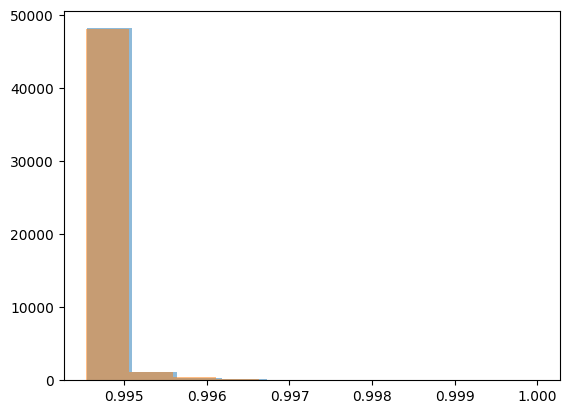

In [24]:
import matplotlib.pyplot as plt
plt.hist(sigmas[d==0], label=0, alpha=0.5)
plt.hist(sigmas[d==1], label=1, alpha=0.5)

(array([ 2572., 14624., 20835., 18460., 13858.,  9784.,  6562.,  4301.,
         2781.,  1911.]),
 array([0.00000000e+00, 2.69928096e-05, 5.39856192e-05, 8.09784251e-05,
        1.07971238e-04, 1.34964052e-04, 1.61956850e-04, 1.88949663e-04,
        2.15942477e-04, 2.42935290e-04, 2.69928103e-04]),
 <BarContainer object of 10 artists>)

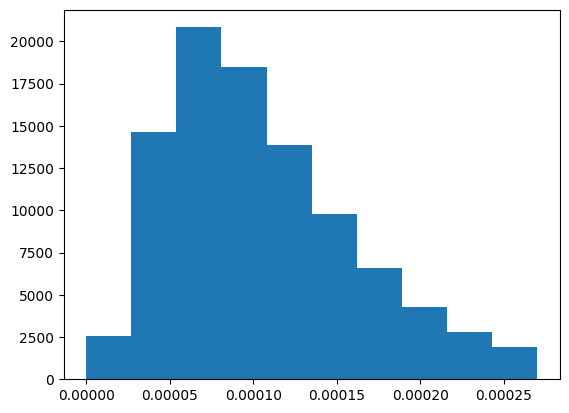

In [ ]:
import numpy as np

def remove_outliers_iqr(data, k=1.5):
    data = np.array(data)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    return (data >= lower_bound) & (data <= upper_bound)


mmm = (sigmas - min(sigmas))/(max(sigmas)-min(sigmas))

plt.hist(remove_outliers_iqr(mmm))

(array([9.989e+04, 5.800e+01, 2.200e+01, 1.100e+01, 9.000e+00, 5.000e+00,
        2.000e+00, 2.000e+00, 0.000e+00, 1.000e+00]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.90000004,
        1.        ]),
 <BarContainer object of 10 artists>)

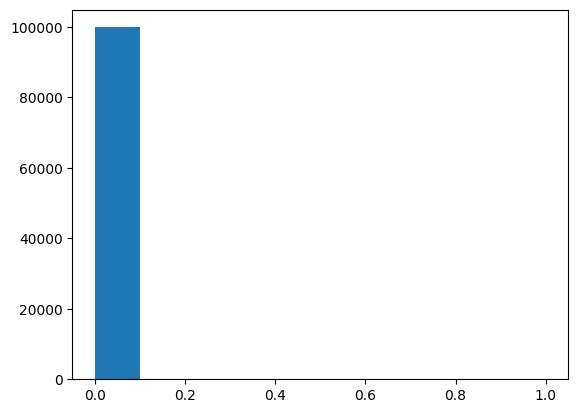

In [23]:
plt.hist((sigmas - min(sigmas))/(max(sigmas)-min(sigmas)))

(array([9.989e+04, 5.800e+01, 2.200e+01, 1.100e+01, 9.000e+00, 5.000e+00,
        2.000e+00, 2.000e+00, 0.000e+00, 1.000e+00]),
 array([5.70041418, 5.82707453, 5.95373535, 6.0803957 , 6.20705605,
        6.33371639, 6.46037722, 6.58703756, 6.71369839, 6.84035873,
        6.96701908]),
 <BarContainer object of 10 artists>)

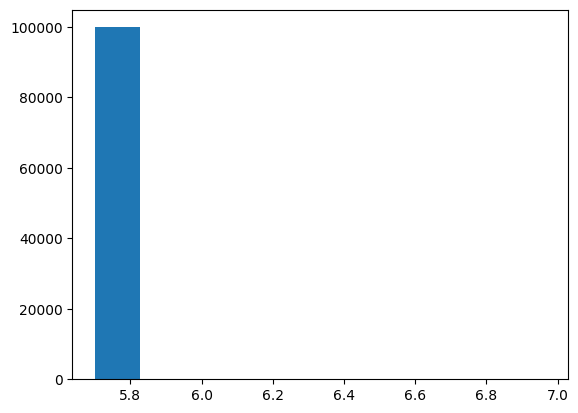

In [22]:
import matplotlib.pyplot as plt
plt.hist(sigmas, bins=10)

In [ ]:
def logistic_auc_test(h, sigma, d, cv_folds=5):
    """
    Compare AUROC of logistic models using H only vs (H, sigma).
    
    Returns:
    - mean AUROC H-only
    - mean AUROC H+sigma
    """
    X_h = h.reshape(-1, 1)
    X_hs = np.hstack([h.reshape(-1,1), sigma.reshape(-1,1)])
    
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=0)
    auc_h = []
    auc_hs = []
    
    for train_idx, test_idx in skf.split(X_h, d):
        # Model H-only
        clf_h = LogisticRegression().fit(X_h[train_idx], d[train_idx])
        preds_h = clf_h.predict_proba(X_h[test_idx])[:, 1]
        auc_h.append(roc_auc_score(d[test_idx], preds_h))
        
        # Model H+sigma
        clf_hs = LogisticRegression().fit(X_hs[train_idx], d[train_idx])
        preds_hs = clf_hs.predict_proba(X_hs[test_idx])[:, 1]
        auc_hs.append(roc_auc_score(d[test_idx], preds_hs))
        
    return np.mean(auc_h), np.mean(auc_hs)
auc_h, auc_hs = logistic_auc_test(h, sigma, d)
print(f"AUROC H only: {auc_h:.3f}, H+sigma: {auc_hs:.3f}")